In [1]:
pwd

'/home/omen/Documents/Nafisha/brainAge/Yale_longitudinal_dataset_inf'

In [2]:
import os
os.chdir('/home/omen/Documents/Rishabh/rp-ai-Triamese-ViT-v2')

In [3]:
import os
import torch
from model.MultiViewViT import MultiViewViT
from load_data import IMG_Folder
import torch.nn as nn

In [4]:
def weights_init(w):
    classname = w.__class__.__name__
    if classname.find('Conv') != -1:
        if hasattr(w, 'weight'):
            # nn.init.kaiming_normal_(w.weight, mode='fan_out', nonlinearity='relu')
            nn.init.kaiming_normal_(w.weight, mode='fan_in', nonlinearity='leaky_relu')
        if hasattr(w, 'bias') and w.bias is not None:
                nn.init.constant_(w.bias, 0)
    if classname.find('Linear') != -1:
        if hasattr(w, 'weight'):
            torch.nn.init.xavier_normal_(w.weight)
        if hasattr(w, 'bias') and w.bias is not None:
            nn.init.constant_(w.bias, 0)
    if classname.find('BatchNorm') != -1:
        if hasattr(w, 'weight') and w.weight is not None:
            nn.init.constant_(w.weight, 1)
        if hasattr(w, 'bias') and w.bias is not None:
            nn.init.constant_(w.bias, 0)

In [5]:
# Load model
model = MultiViewViT(
    image_sizes=[(91, 109), (91, 91), (109, 91)],
    patch_sizes=[(7, 7), (7, 7), (7, 7)],
    num_channals=[91, 109, 91],
    vit_args={
        'emb_dim': 768, 'mlp_dim': 3072, 'num_heads': 12,
        'num_layers': 12, 'num_classes': 1,
        'dropout_rate': 0.1, 'attn_dropout_rate': 0.0
    },
    mlp_dims=[3, 128, 256, 512, 1024, 512, 256, 128, 1]
)
model.apply(weights_init)
model = model.to("cpu")

# Load checkpoint
CheckpointPath = '/home/omen/Documents/Rishabh/rp-ai-Triamese-ViT-v2/output_dirMulti_VIT_best_model_with_harmonization.pth.tar'
checkpoint = torch.load(CheckpointPath, map_location="cpu")
state_dict = checkpoint["state_dict"]
new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
model.load_state_dict(new_state_dict)

<All keys matched successfully>

In [8]:
import pandas as pd
CheckpointPath = '/home/omen/Documents/Rishabh/rp-ai-Triamese-ViT-v2/output_dirMulti_VIT_best_model_with_harmonization.pth.tar'
CSVPath = '/home/omen/Documents/Nafisha/brainAge/CSVs/Yale_vit.xlsx'
DataFolder =  '/home/omen/Documents/Nafisha/brainAge/Yale_preprocessed_data'
# TrainPath = r'C:\Users\Rishabh\Balancedmeanandstd_dataset\Balancedmeanandstd_dataset\NTrain'
# ValPath = r'C:\Users\Rishabh\Balancedmeanandstd_dataset\Balancedmeanandstd_dataset\NVal'
# TestPath = r'C:\Users\Rishabh\Balancedmeanandstd_dataset\Balancedmeanandstd_dataset\NTest'
device = "cpu"
Files = os.listdir(DataFolder)
# ixi_ids = [int(f[3:6]) for f in Files]

In [9]:
data = IMG_Folder( CSVPath
                        ,DataFolder)

In [10]:
data_loader = torch.utils.data.DataLoader(  data
                                            ,batch_size=1
                                            ,num_workers=0
                                            ,pin_memory=True
                                            ,drop_last=True
                                            ,shuffle=True
                                            )

In [11]:
Files[0]

'YG_56EM94BY1R0H_2015-03-12_10-59-38_PRE.nii.gz'

In [12]:
df = pd.read_excel(CSVPath)
df

,file_name,age,sex
0,YG_14VQNND2SXVU_2020-01-11_11-40-00_PRE.nii.gz,32,0
1,YG_14VQNND2SXVU_2020-02-22_11-16-48_PRE.nii.gz,32,0
2,YG_1SHC5E262EIK_2014-12-01_13-13-27_PRE.nii.gz,70,1
3,YG_1SHC5E262EIK_2015-02-28_10-33-06_PRE.nii.gz,71,0
4,YG_1SHC5E262EIK_2015-03-11_18-28-04_PRE.nii.gz,71,0
...,...,...,...
223,YG_XKG0NA8F2QHE_2017-08-08_17-38-14_PRE.nii.gz,89,1
224,YG_XKG0NA8F2QHE_2017-11-29_10-06-22_PRE.nii.gz,89,1
225,YG_XKG0NA8F2QHE_2018-02-21_09-27-48_PRE.nii.gz,89,1
226,YG_XKG0NA8F2QHE_2018-07-05_13-06-35_PRE.nii.gz,89,1


In [13]:
import numpy as np
use_gender = True
model.eval()
Attn1 = []
Attn2 = []
Attn3 = []
Attn1 = torch.zeros((12, 1, 12, 196, 196))
Attn2 = torch.zeros((12, 1, 12, 170, 170))
Attn3 = torch.zeros((12, 1, 12, 196, 196))
samples_processed = 0
with torch.no_grad():
    for _, (input,_,target,male) in enumerate(data_loader):
        # input = input.type(torch.FloatTensor)
        input = input.to(device)

        # =========== convert male lable to one hot type =========== #
        # if use_gender:
        #     male = torch.unsqueeze(male,1)
        #     male = torch.zeros(male.shape[0],2).scatter_(1,male,1)
        #     male = male.to(device).type(torch.FloatTensor)
        target = torch.from_numpy(np.expand_dims(target,axis=1))
        target = target.type(torch.FloatTensor).to(device)


        out, (attn1, attn2, attn3) = model(input, return_attention_weights=True)
        print(attn1[0].shape,' ', attn2[0].shape, ' ',attn3[0].shape )
        Attn1 = Attn1 + torch.stack(attn1)
        Attn2 = Attn2 + torch.stack(attn2)
        Attn3 = Attn3 + torch.stack(attn3)
        samples_processed = samples_processed + 1
        # Attn1.append(torch.stack(attn1))
        # Attn2.append(torch.stack(attn2))
        # Attn3.append(torch.stack(attn3))

torch.Size([1, 12, 196, 196])   torch.Size([1, 12, 170, 170])   torch.Size([1, 12, 196, 196])
torch.Size([1, 12, 196, 196])   torch.Size([1, 12, 170, 170])   torch.Size([1, 12, 196, 196])
torch.Size([1, 12, 196, 196])   torch.Size([1, 12, 170, 170])   torch.Size([1, 12, 196, 196])
torch.Size([1, 12, 196, 196])   torch.Size([1, 12, 170, 170])   torch.Size([1, 12, 196, 196])
torch.Size([1, 12, 196, 196])   torch.Size([1, 12, 170, 170])   torch.Size([1, 12, 196, 196])
torch.Size([1, 12, 196, 196])   torch.Size([1, 12, 170, 170])   torch.Size([1, 12, 196, 196])
torch.Size([1, 12, 196, 196])   torch.Size([1, 12, 170, 170])   torch.Size([1, 12, 196, 196])
torch.Size([1, 12, 196, 196])   torch.Size([1, 12, 170, 170])   torch.Size([1, 12, 196, 196])
torch.Size([1, 12, 196, 196])   torch.Size([1, 12, 170, 170])   torch.Size([1, 12, 196, 196])
torch.Size([1, 12, 196, 196])   torch.Size([1, 12, 170, 170])   torch.Size([1, 12, 196, 196])
torch.Size([1, 12, 196, 196])   torch.Size([1, 12, 170, 170]

In [14]:
Attn1 = Attn1/samples_processed
Attn2 = Attn2/samples_processed
Attn3 = Attn3/samples_processed
samples_processed, Attn1.shape, Attn2.shape, Attn3.shape

(684,
 torch.Size([12, 1, 12, 196, 196]),
 torch.Size([12, 1, 12, 170, 170]),
 torch.Size([12, 1, 12, 196, 196]))

In [15]:
Attn1.shape, Attn2.shape, Attn3.shape

(torch.Size([12, 1, 12, 196, 196]),
 torch.Size([12, 1, 12, 170, 170]),
 torch.Size([12, 1, 12, 196, 196]))

In [16]:
attn1 = Attn1 
attn2 = Attn2 
attn3 = Attn3 

attn1 = torch.mean(attn1, dim=0)
attn1 = torch.mean(attn1, dim=0)
# attn1 = torch.mean(attn1, dim=0)
# attn1 = torch.mean(attn1, dim=0)

attn2 = torch.mean(attn2, dim=0)
attn2 = torch.mean(attn2, dim=0)
# attn2 = torch.mean(attn2, dim=0)
# attn2 = torch.mean(attn2, dim=0)

attn3 = torch.mean(attn3, dim=0)
attn3 = torch.mean(attn3, dim=0)
# attn3 = torch.mean(attn3, dim=0)
# attn3 = torch.mean(attn3, dim=0)

In [17]:
import nibabel as nib
import numpy as np
SampleFilesDir = '/home/omen/Documents/Nafisha/brainAge/Yale_preprocessed_data'
SampleFiles = os.listdir(SampleFilesDir)
filename = SampleFiles[15]
file_path = os.path.join(SampleFilesDir, filename)
img = nib.load(file_path)
x_np = img.get_fdata(caching='unchanged').astype(np.float32)       # avoid float64 bloat

In [18]:
file_path

'/home/omen/Documents/Nafisha/brainAge/Yale_preprocessed_data/YG_TJWUT9VEIOTK_2019-01-07_07-14-53_PRE_stand_mean.nii.gz'

In [19]:
#attention rollout
import cv2
att_mat = attn1
residual_att = torch.eye(att_mat.size(1)).to(device="cpu")
aug_att_mat = att_mat + residual_att
aug_att_mat = aug_att_mat / aug_att_mat.sum(dim=-1).unsqueeze(-1)

# Recursively multiply the weight matrices
joint_attentions = torch.zeros(aug_att_mat.size()).to(device="cpu")
joint_attentions[0] = aug_att_mat[0]

for n in range(1, aug_att_mat.size(0)):
    joint_attentions[n] = torch.matmul(aug_att_mat[n], joint_attentions[n - 1])

# Attention from the output token to the input space.
joint_attentions = joint_attentions[-1]
# joint_attentions = joint_attentions[5]
v = joint_attentions[0, 1:].to(device="cpu")
print(len(v))
print(v.shape)
mask1 = v.reshape(13, 15).detach().numpy()
mask1 = cv2.resize(mask1 / mask1.max(), (91,109))
im = x_np
print(im[91//2, :,:].shape)
attnmask1 = (mask1 * im[91//2, :,:])

195
torch.Size([195])
(109, 91)


In [20]:
import cv2
att_mat = attn2
residual_att = torch.eye(att_mat.size(1)).to(device="cpu")
aug_att_mat = att_mat + residual_att
aug_att_mat = aug_att_mat / aug_att_mat.sum(dim=-1).unsqueeze(-1)

# Recursively multiply the weight matrices
joint_attentions = torch.zeros(aug_att_mat.size()).to(device="cpu")
joint_attentions[0] = aug_att_mat[0]

for n in range(1, aug_att_mat.size(0)):
    joint_attentions[n] = torch.matmul(aug_att_mat[n], joint_attentions[n - 1])

# Attention from the output token to the input space.
joint_attentions = joint_attentions[-1]
v = joint_attentions[0,1:].to(device="cpu")
print(len(v))
mask2 = v.reshape(13, 13).detach().numpy()
mask2 = cv2.resize(mask2 / mask2.max(), (91,91))
im = x_np
print(mask2.shape)
print(im[91//2, :,:].shape)
attnmask2 = (mask2 * im[:,109//2,:])

169
(91, 91)
(109, 91)


In [21]:
import cv2
att_mat = attn3
residual_att = torch.eye(att_mat.size(1)).to(device="cpu")
aug_att_mat = att_mat + residual_att
aug_att_mat = aug_att_mat / aug_att_mat.sum(dim=-1).unsqueeze(-1)

# Recursively multiply the weight matrices
joint_attentions = torch.zeros(aug_att_mat.size()).to(device="cpu")
joint_attentions[0] = aug_att_mat[0]

for n in range(1, aug_att_mat.size(0)):
    joint_attentions[n] = torch.matmul(aug_att_mat[n], joint_attentions[n - 1])

# Attention from the output token to the input space.
joint_attentions = joint_attentions[-1]
# joint_attentions = joint_attentions[1]
v = joint_attentions[0,1:].to(device="cpu")
print(len(v))
mask3 = v.reshape(15, 13).detach().numpy()
mask3 = cv2.resize(mask3 / mask3.max(), (109,91))
im = x_np
print(im[:,:, 91//2].shape)
attnmask3 = (mask3 * im[:,:, 91//2])

195
(91, 109)


(91, 109)


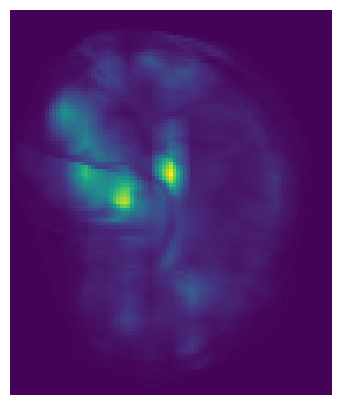

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Example: pick a middle slice along z-axis
slice_idx = x_np.shape[2] // 2  

img_slice = x_np[:, :, slice_idx]
print(img_slice.shape)
mask_slice = mask1

plt.figure(figsize=(10,5))

# Show base image
plt.imshow(attnmask1)

# Overlay mask with transparency
# plt.imshow(mask_slice, cmap='jet', alpha=0.5)  # alpha controls overlay strength
# plt.colorbar(label="Mask intensity")
plt.axis("off")

# plt.savefig("1.png", bbox_inches="tight", dpi=300)  # save as PNG
# plt.savefig("overlay.pdf")  # alternative: save as PDF

plt.show()

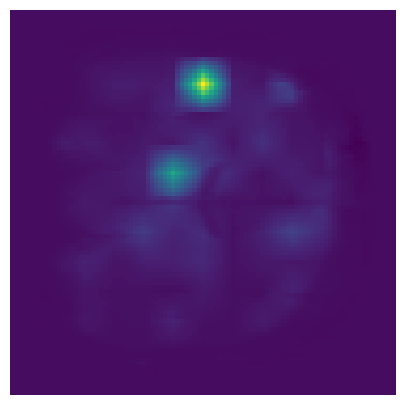

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Example: pick a middle slice along z-axis
slice_idx = x_np.shape[0] // 2  

img_slice = x_np[slice_idx, :, :]
mask_slice = mask3

plt.figure(figsize=(10,5))

# Show base image
plt.imshow(attnmask2)

# Overlay mask with transparency
# plt.imshow(mask_slice, cmap='jet', alpha=0.5)  # alpha controls overlay strength
# plt.colorbar(label="Mask intensity")
plt.axis("off")
# plt.savefig("2.png", bbox_inches="tight", dpi=300)  # save as PNG
plt.show()

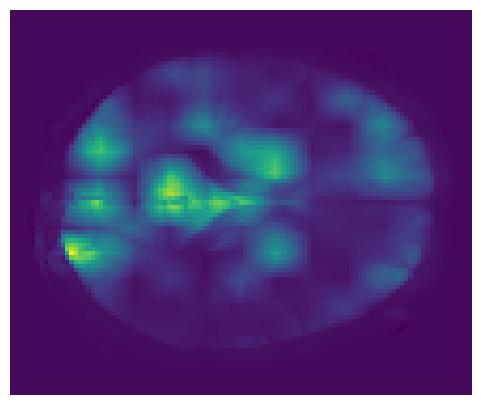

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Example: pick a middle slice along z-axis
slice_idx = x_np.shape[0] // 2  

img_slice = x_np[:, slice_idx, :]
mask_slice = mask3

plt.figure(figsize=(10,5))

# Show base image
plt.imshow(attnmask3)

# Overlay mask with transparency
# plt.imshow(mask_slice, cmap='jet', alpha=0.5)  # alpha controls overlay strength
# plt.colorbar(label="Mask intensity")
plt.axis("off")
# plt.savefig("3.png", bbox_inches="tight", dpi=300)  # save as PNG
plt.show()

In [25]:
attnmask1.shape, attnmask2.shape, attnmask3.shape

((109, 91), (91, 91), (91, 109))

In [26]:
from nilearn import datasets

# ======== Load AAL atlas ======== #
aal_atlas = datasets.fetch_atlas_aal()
atlas_filename = aal_atlas.maps
atlas_nii = nib.load(atlas_filename)
atlas_data = atlas_nii.get_fdata()
# region_labels = np.unique(atlas_data)[1:]  # Exclude 0 (background)
region_labels = np.unique(atlas_data)  # Exclude 0 (background)
region_mapping = {code: label for code, label in zip(region_labels, aal_atlas.labels)}

print(f"Number of regions in atlas: {len(region_labels)}")
print(f"Atlas shape: {atlas_data.shape}")

/tmp/ipykernel_1236307/27463656.py:4: DeprecationWarning: Starting in version 0.13, the default fetched mask will beAAL 3v2 instead.
  aal_atlas = datasets.fetch_atlas_aal()


[fetch_atlas_aal] Dataset found in /home/omen/nilearn_data/aal_SPM12
Number of regions in atlas: 117
Atlas shape: (91, 109, 91)


In [27]:
Attn1_slice = atlas_data[91//2, :, :]
Attn2_slice = atlas_data[:, 109//2, :]
Attn3_slice = atlas_data[ :, :, 91//2]

In [28]:
Attn1_slice.shape, Attn2_slice.shape, Attn3_slice.shape

((109, 91), (91, 91), (91, 109))

In [29]:
np.unique(Attn1_slice), np.unique(Attn2_slice), np.unique(Attn3_slice)

(array([   0., 2401., 2402., 2501., 2601., 2611., 2612., 2701., 2702.,
        4001., 4002., 4011., 4012., 4021., 5001., 5011., 5021., 6301.,
        6302., 6401., 6402., 7101., 9011., 9071., 9100., 9110., 9120.,
        9130., 9140., 9150., 9160., 9170.]),
 array([   0., 2001., 2002., 2102., 2331., 2332., 2401., 2402., 3001.,
        3002., 4011., 4012., 4101., 4102., 4111., 4112., 5401., 5402.,
        6001., 6002., 6211., 6212., 6401., 6402., 7001., 7002., 7011.,
        7012., 7101., 7102., 8101., 8102., 8111., 8112., 8201., 8202.,
        8301., 8302.]),
 array([   0., 2001., 2002., 2101., 2102., 2201., 2202., 2301., 2302.,
        2311., 2312., 2331., 2332., 2601., 2602., 3001., 3002., 4001.,
        4002., 4021., 4022., 5001., 5002., 5011., 5012., 5101., 5102.,
        5201., 5202., 6001., 6002., 6211., 6212., 6301., 6302., 7001.,
        7002., 7101., 7102., 8111., 8112., 8201., 8202.]))

In [30]:
np.unique(mask1), np.unique(mask2), np.unique(mask3)

(array([0.00455943, 0.00456474, 0.00456884, ..., 0.8909259 , 0.9110593 ,
        0.94558865], shape=(8957,), dtype=float32),
 array([0.00252523, 0.0028351 , 0.0043625 , ..., 0.86400604, 0.86475813,
        1.        ], shape=(7223,), dtype=float32),
 array([0.00147104, 0.00150155, 0.00156695, ..., 0.8439026 , 0.88275814,
        0.9367242 ], shape=(8959,), dtype=float32))

In [31]:
attention1_dict_name_mean = {}
attention1_dict_name_mean = {}
for region in region_labels:
    # Free up memory
    torch.cuda.empty_cache()

    # Create mask for this region
    region_mask = (Attn1_slice.copy() == region)
    # print(np.unique(region_mask))
    
    masked_input = mask1.copy()
    # print(np.unique(masked_input))

    attnmask = region_mask*masked_input
    average_value = np.mean(attnmask)
    print(region, '  ',region_mapping[region],'  ', average_value)
    attention1_dict_name_mean[region_mapping[region]] = average_value
    

sorted_dict1 = dict(sorted(attention1_dict_name_mean.items(), key=lambda item: item[1]))

0.0    Background    0.022525717
2001.0    Precentral_L    0.0
2002.0    Precentral_R    0.0
2101.0    Frontal_Sup_L    0.0
2102.0    Frontal_Sup_R    0.0
2111.0    Frontal_Sup_Orb_L    0.0
2112.0    Frontal_Sup_Orb_R    0.0
2201.0    Frontal_Mid_L    0.0
2202.0    Frontal_Mid_R    0.0
2211.0    Frontal_Mid_Orb_L    0.0
2212.0    Frontal_Mid_Orb_R    0.0
2301.0    Frontal_Inf_Oper_L    0.0
2302.0    Frontal_Inf_Oper_R    0.0
2311.0    Frontal_Inf_Tri_L    0.0
2312.0    Frontal_Inf_Tri_R    0.0
2321.0    Frontal_Inf_Orb_L    0.0
2322.0    Frontal_Inf_Orb_R    0.0
2331.0    Rolandic_Oper_L    0.0
2332.0    Rolandic_Oper_R    0.0
2401.0    Supp_Motor_Area_L    0.0006751117
2402.0    Supp_Motor_Area_R    2.1381916e-06
2501.0    Olfactory_L    7.051784e-05
2502.0    Olfactory_R    0.0
2601.0    Frontal_Sup_Medial_L    0.0013599066
2602.0    Frontal_Sup_Medial_R    0.0
2611.0    Frontal_Med_Orb_L    0.0002692528
2612.0    Frontal_Med_Orb_R    5.5019187e-05
2701.0    Rectus_L    0.00021546829

In [32]:
sorted_dict1

{'Precentral_L': np.float32(0.0),
 'Precentral_R': np.float32(0.0),
 'Frontal_Sup_L': np.float32(0.0),
 'Frontal_Sup_R': np.float32(0.0),
 'Frontal_Sup_Orb_L': np.float32(0.0),
 'Frontal_Sup_Orb_R': np.float32(0.0),
 'Frontal_Mid_L': np.float32(0.0),
 'Frontal_Mid_R': np.float32(0.0),
 'Frontal_Mid_Orb_L': np.float32(0.0),
 'Frontal_Mid_Orb_R': np.float32(0.0),
 'Frontal_Inf_Oper_L': np.float32(0.0),
 'Frontal_Inf_Oper_R': np.float32(0.0),
 'Frontal_Inf_Tri_L': np.float32(0.0),
 'Frontal_Inf_Tri_R': np.float32(0.0),
 'Frontal_Inf_Orb_L': np.float32(0.0),
 'Frontal_Inf_Orb_R': np.float32(0.0),
 'Rolandic_Oper_L': np.float32(0.0),
 'Rolandic_Oper_R': np.float32(0.0),
 'Olfactory_R': np.float32(0.0),
 'Frontal_Sup_Medial_R': np.float32(0.0),
 'Insula_L': np.float32(0.0),
 'Insula_R': np.float32(0.0),
 'Cingulum_Post_R': np.float32(0.0),
 'Hippocampus_L': np.float32(0.0),
 'Hippocampus_R': np.float32(0.0),
 'ParaHippocampal_L': np.float32(0.0),
 'ParaHippocampal_R': np.float32(0.0),
 'Amyg

In [33]:
attention2_dict_name_mean = {}
attention2_dict_name_mean = {}
for region in region_labels:
    # Free up memory
    torch.cuda.empty_cache()

    # Create mask for this region
    region_mask = (Attn2_slice.copy() == region)
    # print(np.unique(region_mask))
    
    masked_input = mask2.copy()
    # print(np.unique(masked_input))

    attnmask = region_mask*masked_input
    average_value = np.mean(attnmask)
    print(region, '  ',region_mapping[region],'  ', average_value)
    attention2_dict_name_mean[region_mapping[region]] = average_value
    

sorted_dict2 = dict(sorted(attention2_dict_name_mean.items(), key=lambda item: item[1]))

0.0    Background    0.031239688
2001.0    Precentral_L    0.00093856687
2002.0    Precentral_R    0.001244216
2101.0    Frontal_Sup_L    0.0
2102.0    Frontal_Sup_R    1.419101e-05
2111.0    Frontal_Sup_Orb_L    0.0
2112.0    Frontal_Sup_Orb_R    0.0
2201.0    Frontal_Mid_L    0.0
2202.0    Frontal_Mid_R    0.0
2211.0    Frontal_Mid_Orb_L    0.0
2212.0    Frontal_Mid_Orb_R    0.0
2301.0    Frontal_Inf_Oper_L    0.0
2302.0    Frontal_Inf_Oper_R    0.0
2311.0    Frontal_Inf_Tri_L    0.0
2312.0    Frontal_Inf_Tri_R    0.0
2321.0    Frontal_Inf_Orb_L    0.0
2322.0    Frontal_Inf_Orb_R    0.0
2331.0    Rolandic_Oper_L    0.00013202673
2332.0    Rolandic_Oper_R    0.003331661
2401.0    Supp_Motor_Area_L    0.00028141373
2402.0    Supp_Motor_Area_R    0.0005170839
2501.0    Olfactory_L    0.0
2502.0    Olfactory_R    0.0
2601.0    Frontal_Sup_Medial_L    0.0
2602.0    Frontal_Sup_Medial_R    0.0
2611.0    Frontal_Med_Orb_L    0.0
2612.0    Frontal_Med_Orb_R    0.0
2701.0    Rectus_L    0.0
2

In [34]:
sorted_dict2

{'Frontal_Sup_L': np.float32(0.0),
 'Frontal_Sup_Orb_L': np.float32(0.0),
 'Frontal_Sup_Orb_R': np.float32(0.0),
 'Frontal_Mid_L': np.float32(0.0),
 'Frontal_Mid_R': np.float32(0.0),
 'Frontal_Mid_Orb_L': np.float32(0.0),
 'Frontal_Mid_Orb_R': np.float32(0.0),
 'Frontal_Inf_Oper_L': np.float32(0.0),
 'Frontal_Inf_Oper_R': np.float32(0.0),
 'Frontal_Inf_Tri_L': np.float32(0.0),
 'Frontal_Inf_Tri_R': np.float32(0.0),
 'Frontal_Inf_Orb_L': np.float32(0.0),
 'Frontal_Inf_Orb_R': np.float32(0.0),
 'Olfactory_L': np.float32(0.0),
 'Olfactory_R': np.float32(0.0),
 'Frontal_Sup_Medial_L': np.float32(0.0),
 'Frontal_Sup_Medial_R': np.float32(0.0),
 'Frontal_Med_Orb_L': np.float32(0.0),
 'Frontal_Med_Orb_R': np.float32(0.0),
 'Rectus_L': np.float32(0.0),
 'Rectus_R': np.float32(0.0),
 'Cingulum_Ant_L': np.float32(0.0),
 'Cingulum_Ant_R': np.float32(0.0),
 'Cingulum_Post_L': np.float32(0.0),
 'Cingulum_Post_R': np.float32(0.0),
 'Amygdala_L': np.float32(0.0),
 'Amygdala_R': np.float32(0.0),
 'Cal

In [35]:
attention3_dict_name_mean = {}
attention3_dict_name_mean = {}
for region in region_labels:
    # Free up memory
    torch.cuda.empty_cache()

    # Create mask for this region
    region_mask = (Attn3_slice.copy() == region)
    # print(np.unique(region_mask))
    
    masked_input = mask3.copy()
    # print(np.unique(masked_input))

    attnmask = region_mask*masked_input
    average_value = np.mean(attnmask)
    print(region, '  ',region_mapping[region],'  ', average_value)
    attention3_dict_name_mean[region_mapping[region]] = average_value
    

sorted_dict3 = dict(sorted(attention3_dict_name_mean.items(), key=lambda item: item[1]))

0.0    Background    0.026772017
2001.0    Precentral_L    2.8688502e-05
2002.0    Precentral_R    6.153938e-05
2101.0    Frontal_Sup_L    0.00026715852
2102.0    Frontal_Sup_R    0.000597861
2111.0    Frontal_Sup_Orb_L    0.0
2112.0    Frontal_Sup_Orb_R    0.0
2201.0    Frontal_Mid_L    0.00072867115
2202.0    Frontal_Mid_R    0.00096304395
2211.0    Frontal_Mid_Orb_L    0.0
2212.0    Frontal_Mid_Orb_R    0.0
2301.0    Frontal_Inf_Oper_L    0.00010789283
2302.0    Frontal_Inf_Oper_R    8.049255e-05
2311.0    Frontal_Inf_Tri_L    0.00028227828
2312.0    Frontal_Inf_Tri_R    0.0003564038
2321.0    Frontal_Inf_Orb_L    0.0
2322.0    Frontal_Inf_Orb_R    0.0
2331.0    Rolandic_Oper_L    0.00024403258
2332.0    Rolandic_Oper_R    0.0004993444
2401.0    Supp_Motor_Area_L    0.0
2402.0    Supp_Motor_Area_R    0.0
2501.0    Olfactory_L    0.0
2502.0    Olfactory_R    0.0
2601.0    Frontal_Sup_Medial_L    0.00032461385
2602.0    Frontal_Sup_Medial_R    0.0004432503
2611.0    Frontal_Med_Orb_L 

In [36]:
sorted_dict3

{'Frontal_Sup_Orb_L': np.float32(0.0),
 'Frontal_Sup_Orb_R': np.float32(0.0),
 'Frontal_Mid_Orb_L': np.float32(0.0),
 'Frontal_Mid_Orb_R': np.float32(0.0),
 'Frontal_Inf_Orb_L': np.float32(0.0),
 'Frontal_Inf_Orb_R': np.float32(0.0),
 'Supp_Motor_Area_L': np.float32(0.0),
 'Supp_Motor_Area_R': np.float32(0.0),
 'Olfactory_L': np.float32(0.0),
 'Olfactory_R': np.float32(0.0),
 'Frontal_Med_Orb_L': np.float32(0.0),
 'Frontal_Med_Orb_R': np.float32(0.0),
 'Rectus_L': np.float32(0.0),
 'Rectus_R': np.float32(0.0),
 'Cingulum_Mid_L': np.float32(0.0),
 'Cingulum_Mid_R': np.float32(0.0),
 'Hippocampus_L': np.float32(0.0),
 'Hippocampus_R': np.float32(0.0),
 'ParaHippocampal_L': np.float32(0.0),
 'ParaHippocampal_R': np.float32(0.0),
 'Amygdala_L': np.float32(0.0),
 'Amygdala_R': np.float32(0.0),
 'Lingual_L': np.float32(0.0),
 'Lingual_R': np.float32(0.0),
 'Occipital_Inf_L': np.float32(0.0),
 'Occipital_Inf_R': np.float32(0.0),
 'Fusiform_L': np.float32(0.0),
 'Fusiform_R': np.float32(0.0),


In [ ]:
import numpy as np

avg_dict = {
    key: np.mean([
        sorted_dict1[key],
        sorted_dict2[key],
        sorted_dict3[key]
    ])
    for key in sorted_dict1
}


In [38]:
avg_dict

{'Precentral_L': np.float32(0.00032241846),
 'Precentral_R': np.float32(0.00043525177),
 'Frontal_Sup_L': np.float32(8.905284e-05),
 'Frontal_Sup_R': np.float32(0.00020401734),
 'Frontal_Sup_Orb_L': np.float32(0.0),
 'Frontal_Sup_Orb_R': np.float32(0.0),
 'Frontal_Mid_L': np.float32(0.00024289038),
 'Frontal_Mid_R': np.float32(0.00032101464),
 'Frontal_Mid_Orb_L': np.float32(0.0),
 'Frontal_Mid_Orb_R': np.float32(0.0),
 'Frontal_Inf_Oper_L': np.float32(3.5964276e-05),
 'Frontal_Inf_Oper_R': np.float32(2.683085e-05),
 'Frontal_Inf_Tri_L': np.float32(9.4092764e-05),
 'Frontal_Inf_Tri_R': np.float32(0.00011880126),
 'Frontal_Inf_Orb_L': np.float32(0.0),
 'Frontal_Inf_Orb_R': np.float32(0.0),
 'Rolandic_Oper_L': np.float32(0.00012535311),
 'Rolandic_Oper_R': np.float32(0.0012770018),
 'Olfactory_R': np.float32(0.0),
 'Frontal_Sup_Medial_R': np.float32(0.00014775009),
 'Insula_L': np.float32(0.00012279942),
 'Insula_R': np.float32(0.00018016169),
 'Cingulum_Post_R': np.float32(8.79213e-05),

In [40]:
# Sort avg_dict by values (descending order)
sorted_avg_dict = dict(sorted(avg_dict.items(), key=lambda item: item[1], reverse=True))
sorted_avg_dict

{'Background': np.float32(0.026845807),
 'Rolandic_Oper_R': np.float32(0.0012770018),
 'Thalamus_R': np.float32(0.0012077907),
 'SupraMarginal_R': np.float32(0.00063810515),
 'Cuneus_L': np.float32(0.00062327046),
 'Temporal_Sup_R': np.float32(0.0005776453),
 'Frontal_Sup_Medial_L': np.float32(0.00056150684),
 'Thalamus_L': np.float32(0.000493917),
 'Occipital_Mid_L': np.float32(0.00046779506),
 'Precentral_R': np.float32(0.00043525177),
 'Precuneus_L': np.float32(0.0004341317),
 'Postcentral_R': np.float32(0.0003903232),
 'Cingulum_Ant_L': np.float32(0.0003376229),
 'Occipital_Mid_R': np.float32(0.00033566297),
 'Calcarine_L': np.float32(0.0003281283),
 'Precentral_L': np.float32(0.00032241846),
 'Frontal_Mid_R': np.float32(0.00032101464),
 'Supp_Motor_Area_L': np.float32(0.0003188418),
 'Occipital_Sup_R': np.float32(0.00030128733),
 'Precuneus_R': np.float32(0.000298025),
 'Cingulum_Mid_L': np.float32(0.00029764572),
 'Paracentral_Lobule_L': np.float32(0.00027930297),
 'Caudate_R': n